In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Regression Modeling for Diabetes Progression Prediction

**Objective**: This project focuses on predicting diabetes progression using the full set of features from the SciKit-Learn diabetes dataset. After exploring and preparing the data, multiple regression algorithms are trained and evaluated to identify the most effective modeling approach. Hyperparameter tuning is performed for decision tree and random forest models to optimize their predictive performance. Finally, the results from all candidate models are compared to select the best-performing model for estimating diabetes progression.

# Data Exploration

The diabetes data is a well curated and clean (the data was nicely scaled, had nomissing values, and had minimal skew).

Load the scikit-learn diabetes bunch object into a variable.

In [2]:
# load diabetes dataset
dbt = load_diabetes(as_frame=True)

Create a Pandas DataFrame from the bunch.

In [3]:
# load diabetes data into a df
dbt = dbt.frame

In [4]:
dbt.shape

(442, 11)

In [5]:
dbt.dtypes

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

In [6]:
dbt.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Show histrogram of each feature.

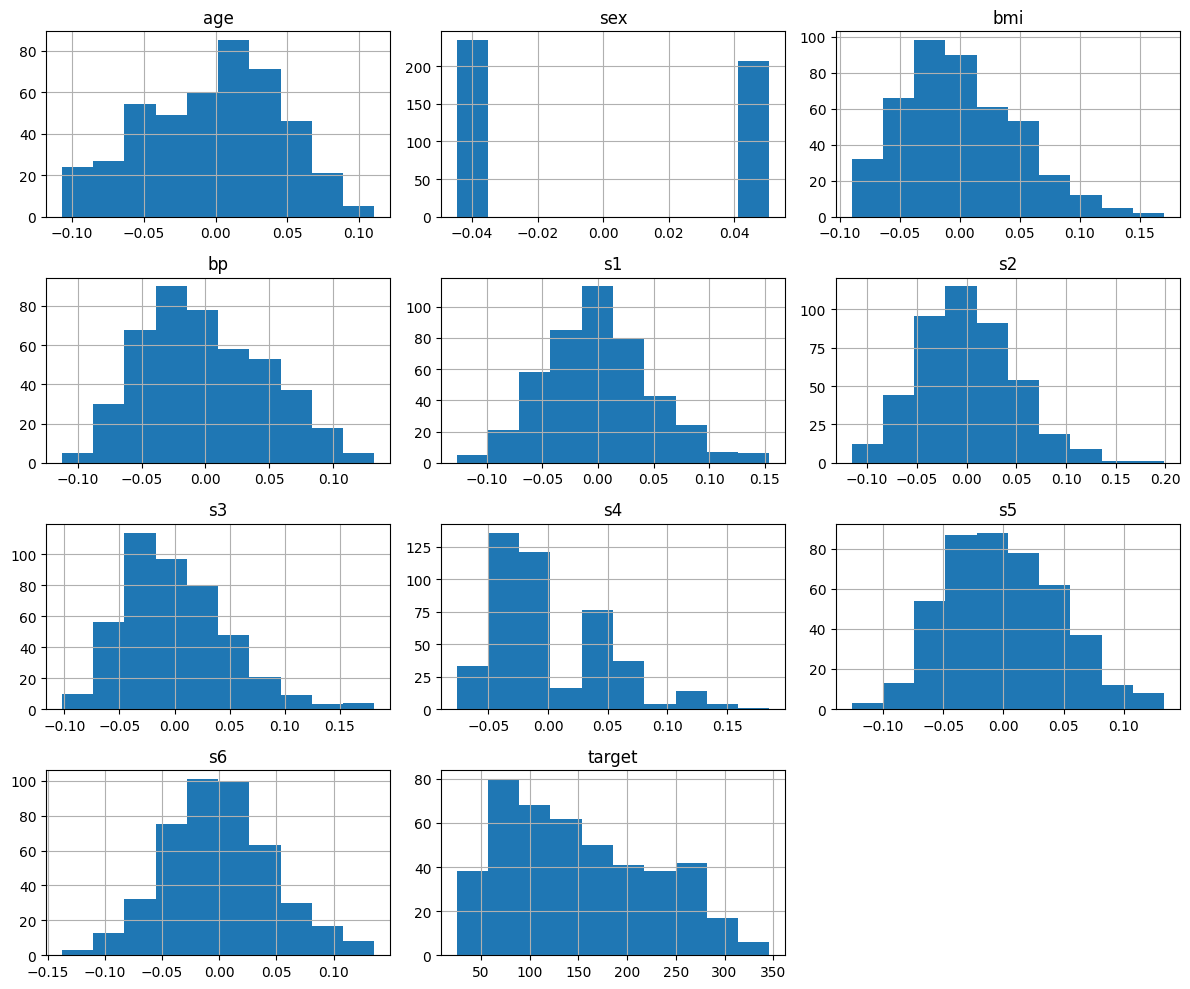

In [7]:
# display histograms for all variables
dbt.hist(figsize= (12, 10))
plt.tight_layout()
plt.show()

In the diabetes dataset, input data features are well scaled, with a near 0 mean and approximately 0.05 standard deviation. The skew shows that distributions of the input variables are low, indicating symmetric distributions. The s3 and s4 distributions are the most skewed, but both skew values are less than 1. The histrograms show that all variables besides sex have normal distributions. Sex has a bimodal distribution. There is no apparent presence of outliers. 

Calculate skew.

In [8]:
dbt.skew()

age      -0.231382
sex       0.127385
bmi       0.598148
bp        0.290658
s1        0.378108
s2        0.436592
s3        0.799255
s4        0.735374
s5        0.291754
s6        0.207917
target    0.440563
dtype: float64

Construct a correlation matrix.

In [9]:
# find the correlation of variables to the target variable
dbt.corr().loc['target', dbt.columns != 'target'].abs().sort_values(ascending=False)

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3     0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64

In order from greatest to least in absolute terms, BMI, s5, BP, s4, s3, s6, s1, age, s2, and then sex are correlated with the target variable.

Examine the scatter plots of the four features with the largest correlations to the target.

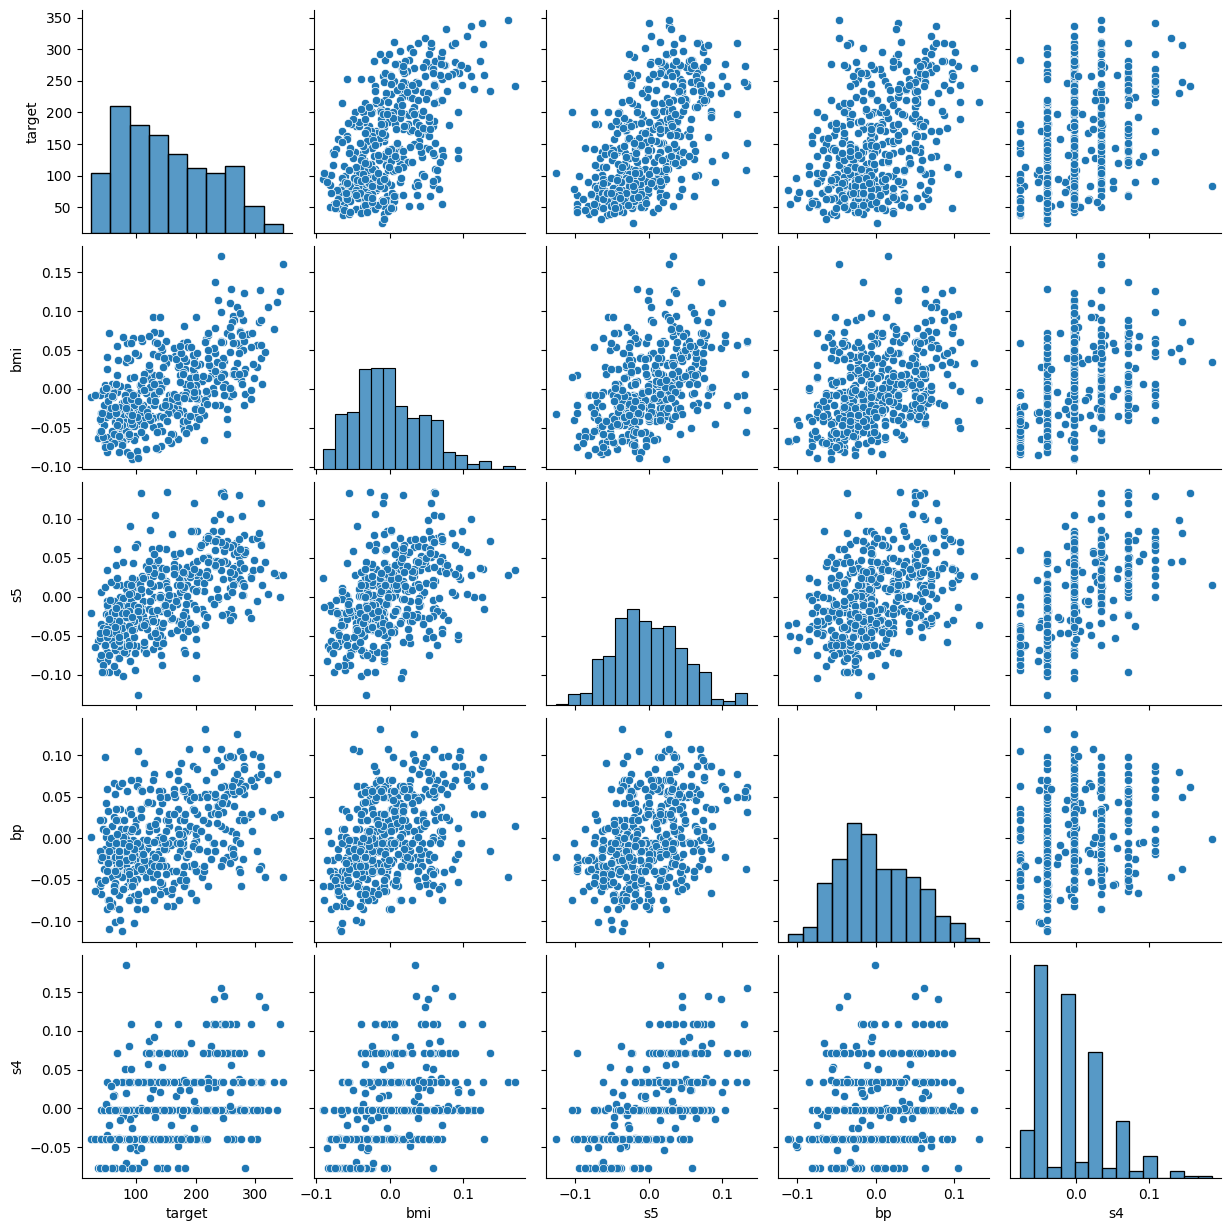

In [10]:
# create pairplot with the four features with the highest correlation to target
sns.pairplot(dbt[['target','bmi','s5','bp','s4']])
plt.show()

Partition the data into training and testing datasets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(dbt.loc[:,dbt.columns != 'target'], dbt[['target']], test_size=.2, random_state=42)

In [12]:
X_train.shape

(353, 10)

In [13]:
y_train.shape

(353, 1)

In [14]:
X_test.shape

(89, 10)

In [15]:
y_test.shape

(89, 1)

# Model Training

Instantiate the following three algorithms :
1. linear regressor
2. decision tree regressor
3. random forest regressor

In [16]:
# linear regressor
lin_reg = LinearRegression(fit_intercept=True)

# decision tree regressor
tree = DecisionTreeRegressor()

# random forest
forest = RandomForestRegressor(random_state=42)

Calculate and print the following:
1. The RMSE output from cross_val_score.
2. The mean of the RMSE values
3. The standard deviation of the RMSE values

In [17]:
# cros val score for linear regression
rmse_lin = cross_val_score(estimator= lin_reg, 
                        X= X_train, 
                        y= y_train, 
                        cv= 5, 
                        scoring= 'neg_root_mean_squared_error')

print("Linear Regression Model")
print(f"1. RMSE output: {-1*rmse_lin}")
print(f"2. Mean RMSE: {-1*np.mean(rmse_lin)}")
print(f"3. Std RMSE: {np.std(rmse_lin)}")

Linear Regression Model
1. RMSE output: [52.53034465 58.93522481 52.08727478 56.50041896 59.80716652]
2. Mean RMSE: 55.972085945473054
3. Std RMSE: 3.1844783466530266


In [18]:
# cros val score for decision tree
rmse_tree = cross_val_score(estimator=tree, 
                        X= X_train, 
                        y= y_train, 
                        cv= 5, 
                        scoring= 'neg_root_mean_squared_error')

print("Decision Tree Model")
print(f"1. RMSE output: {-1*rmse_tree}")
print(f"2. Mean RMSE: {-1*np.mean(rmse_tree)}")
print(f"3. Std RMSE: {np.std(rmse_tree)}")

Decision Tree Model
1. RMSE output: [78.74508704 80.09580531 80.22073421 79.21020858 76.35387538]
2. Mean RMSE: 78.92514210286933
3. Std RMSE: 1.3981492429153415


In [19]:
# cros val score for random forest
rmse_forest = cross_val_score(estimator=forest, 
                        X= X_train, 
                        y= y_train.to_numpy().ravel(), # needed flattened array 
                        cv= 5, 
                        scoring= 'neg_root_mean_squared_error')

print("Random Forest Model")
print(f"1. RMSE output: {-1*rmse_forest}")
print(f"2. Mean RMSE: {-1*np.mean(rmse_forest)}")
print(f"3. Std RMSE: {np.std(rmse_forest)}")

Random Forest Model
1. RMSE output: [54.52038723 68.00166439 56.88656819 60.04114143 55.87601656]
2. Mean RMSE: 59.06515556124806
3. Std RMSE: 4.824634867014727


Using the training data reduced to only bmi, calculate and print the following:
1. The RMSE output from cross_val_score.
2. The mean of the RMSE values
3. The standard deviation of the RMSE values

In [20]:
# cros val score for linear regression with one feature varibale
rmse_lin = cross_val_score(estimator= lin_reg, 
                        X= X_train[['bmi']], 
                        y= y_train, 
                        cv= 5, 
                        scoring= 'neg_root_mean_squared_error')

print("Linear Regression Model from Assignment 1")
print(f"1. RMSE output: {-1*rmse_lin}")
print(f"2. Mean RMSE: {-1*np.mean(rmse_lin)}")
print(f"3. Std RMSE: {np.std(rmse_lin)}")

Linear Regression Model from Assignment 1
1. RMSE output: [62.63654683 65.80955901 58.54772152 65.06090227 61.04527181]
2. Mean RMSE: 62.62000028910842
3. Std RMSE: 2.6531032880526504


# Decision Tree Regressor Tuning

Print the default hyperparameter settings of a decision tree regressor.

In [21]:
# get default hypterparameters for decision tree
tree.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Conduct two independent grid searches to find the optimal max depth and min sample leaf to limit the depth of the tree.

In [22]:
tree_grid = [
    {'max_depth': np.arange(start=1, stop=20)},
    {'min_samples_leaf': np.arange(start=1, stop=51)}
]

tree_grid_search = GridSearchCV(estimator= tree, 
                                param_grid= tree_grid, 
                                cv= 5, 
                                scoring= 'neg_root_mean_squared_error'
                               )

tree_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid=[{'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])},
                         {'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])}],
             scoring='neg_root_mean_squared_error')

Identify the optimal hyperparameter settings.

In [23]:
# optimal hyperparameter settings
tree_grid_search.best_params_

{'max_depth': np.int64(2)}

In [24]:
# best score
-1*tree_grid_search.best_score_

np.float64(61.26383483081285)

Using the cv_results dictionary, pair the hyperparameter values and the corresponding RMSE for each hyperparameter setting combination considered by the grid search and print them.

In [25]:
# print the average RMSE for each hyperparameter setting
for i in range(len(tree_grid_search.cv_results_['params'])):
    print(f'{tree_grid_search.cv_results_['params'][i]}\tRMSE:{-1*tree_grid_search.cv_results_['mean_test_score'][i]}')

{'max_depth': np.int64(1)}	RMSE:66.77484860968592
{'max_depth': np.int64(2)}	RMSE:61.26383483081285
{'max_depth': np.int64(3)}	RMSE:64.6565919141738
{'max_depth': np.int64(4)}	RMSE:65.50626709791283
{'max_depth': np.int64(5)}	RMSE:66.60173828624661
{'max_depth': np.int64(6)}	RMSE:72.16333264198963
{'max_depth': np.int64(7)}	RMSE:76.79447101359037
{'max_depth': np.int64(8)}	RMSE:76.08108202605737
{'max_depth': np.int64(9)}	RMSE:77.72278840133501
{'max_depth': np.int64(10)}	RMSE:79.3092137722656
{'max_depth': np.int64(11)}	RMSE:78.8287418011073
{'max_depth': np.int64(12)}	RMSE:79.47292505902479
{'max_depth': np.int64(13)}	RMSE:81.38493150618734
{'max_depth': np.int64(14)}	RMSE:79.68643765322855
{'max_depth': np.int64(15)}	RMSE:82.02343355403718
{'max_depth': np.int64(16)}	RMSE:78.89104879079828
{'max_depth': np.int64(17)}	RMSE:78.67574760265724
{'max_depth': np.int64(18)}	RMSE:80.95167504271228
{'max_depth': np.int64(19)}	RMSE:79.71343407274891
{'min_samples_leaf': np.int64(1)}	RMSE:80.0

# Random Forest Regressor Tuning

Print the default parameters of this random forest regressor.

In [26]:
# default settings for random forest model
forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

Hyperparametertune using GridSearchCV.

In [27]:
forest_grid = {
        'n_estimators': [100, 200, 400, 500],
        'max_features': [2, 4, 6, 8, 10]
}

forest_grid_search = GridSearchCV(estimator= forest, 
                                param_grid= forest_grid, 
                                cv= 5, 
                                scoring= 'neg_root_mean_squared_error'
                               )

forest_grid_search.fit(X_train, y_train.to_numpy().ravel())

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_features': [2, 4, 6, 8, 10],
                         'n_estimators': [100, 200, 400, 500]},
             scoring='neg_root_mean_squared_error')

Print out the best hyperparameter settings and best score found from this grid search

In [28]:
# optimal hyperparameter settings
forest_grid_search.best_params_

{'max_features': 4, 'n_estimators': 200}

In [29]:
# best score
-1*forest_grid_search.best_score_

np.float64(57.57507001282626)

In [30]:
# print the average RMSE for each hyperparameter setting
for i in range(len(forest_grid_search.cv_results_['params'])):
    print(f'{forest_grid_search.cv_results_['params'][i]}\tRMSE:{-1*forest_grid_search.cv_results_['mean_test_score'][i]}')

{'max_features': 2, 'n_estimators': 100}	RMSE:58.649452799796734
{'max_features': 2, 'n_estimators': 200}	RMSE:58.13767879698598
{'max_features': 2, 'n_estimators': 400}	RMSE:58.049023173204965
{'max_features': 2, 'n_estimators': 500}	RMSE:57.984527058772656
{'max_features': 4, 'n_estimators': 100}	RMSE:57.65431968047848
{'max_features': 4, 'n_estimators': 200}	RMSE:57.57507001282626
{'max_features': 4, 'n_estimators': 400}	RMSE:57.6666950995491
{'max_features': 4, 'n_estimators': 500}	RMSE:57.699352335625385
{'max_features': 6, 'n_estimators': 100}	RMSE:57.94562498338828
{'max_features': 6, 'n_estimators': 200}	RMSE:57.73342929186282
{'max_features': 6, 'n_estimators': 400}	RMSE:57.78909285370817
{'max_features': 6, 'n_estimators': 500}	RMSE:57.71183622017836
{'max_features': 8, 'n_estimators': 100}	RMSE:58.9221775692852
{'max_features': 8, 'n_estimators': 200}	RMSE:58.563631825844325
{'max_features': 8, 'n_estimators': 400}	RMSE:58.23306716268026
{'max_features': 8, 'n_estimators': 5

Identify the feature importances from the best estimator, pair the importance values with their corresponding feature, and print the feature, importance pairs.

In [31]:
# create random forest model with best params
forest_best = RandomForestRegressor(max_features=4,
                                    n_estimators=200,
                                    random_state=42)

# fit model
forest_best.fit(X_train, y_train.to_numpy().ravel())

RandomForestRegressor(max_features=4, n_estimators=200, random_state=42)

In [32]:
# create df to hold importances
forest_import_df = {'feature':forest_best.feature_names_in_,
                      'importances': forest_best.feature_importances_}
forest_import_df = pd.DataFrame(forest_import_df)

# display importances ordered by importance
forest_import_df.sort_values(by='importances', ascending=False)

,feature,importances
2,bmi,0.276136
8,s5,0.205969
3,bp,0.113577
9,s6,0.081539
6,s3,0.072997
5,s2,0.064550
4,s1,0.059292
0,age,0.059107
7,s4,0.055029
1,sex,0.011804


The feature importances from our tuned random forest model are similar to the correlations between the input variables and the target variable. The three variables with the highest correlation with the target variable, BMI, s5, and BP, were also the three variables with the highest feature importances in our random forest model.

# Model Evaluation and Selection

The average RMSE of our untuned models
- Linear Regressor with entire training data: 55.97
- Decision Tree Regressor: 80.60
- Random Forest Regressor: 59.07
- Linear Regressor with the single best feature found in Assignment 1: 62.62

The average RMSE of our tuned models
- Best Decision Tree Regressor: 61.26
- Best Random Forest Model: 57.58  

Of all the models created, the linear regressor with all features from the training data was the best performing model, with an average RMSE of 55.97.

Use the best performing model identified to make predictions with the test set.

In [33]:
# train linear regression model on training set
lin_reg.fit(X_train, y_train)

# predict on the test set
y_test_predict = lin_reg.predict(X_test)

In [34]:
# calculate RMSE
rmse_lin_reg_test = np.sqrt(mean_squared_error(y_test, y_test_predict))

rmse_lin_reg_test 

np.float64(53.85344583676593)

The RMSE of the test set, 53,85, is marginarlly lower than that the average RMSE of the training set found from cross validation, 55.97. This indicates that the model does not over or under fit the data. 